In [ ]:
from typing import TypedDict, Annotated, List
from operator import add
from langchain_core.messages import BaseMessage

In [ ]:
class MessagesState_Manual(TypedDict):
  message: Annotated[List[BaseMessage], add]

In [ ]:
# Or instead we Can directly import this memory window Funtion from the Langraph
from langgraph.graph import MessagesState
class MessagesState(MessagesState):
  pass

In [ ]:
pip install -U langchain-google-genai

In [ ]:
## For chat bot we need Interactive Message so first wen need LLM
import os
from google.colab import userdata
os.environ['GOOGLE_API_KEY']=userdata.get('GEMINI3')

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm=ChatGoogleGenerativeAI(
    model="gemini-2.5-flash")

In [ ]:
# Creating NODES
def ChatAI(state: MessagesState_Manual):
  response=llm.invoke(state['message'])
  return {'message': [response.content]} # BE CAREFULL THIS MUST BE LIST

In [ ]:
from langgraph.graph import StateGraph, START, END

In [ ]:
GraphVar=StateGraph(MessagesState_Manual)

In [ ]:
GraphVar.add_node('NODE1', ChatAI)

In [ ]:
GraphVar.add_edge(START,"NODE1" )
GraphVar.add_edge("NODE1", END )

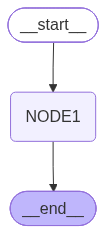

In [ ]:
graph=GraphVar.compile()
graph

In [ ]:
from langchain_core.messages import SystemMessage, HumanMessage

In [ ]:
graph.invoke({
    'message': ["Hi There How are you"]
})

{'message': ['Hi There How are you',
  "Hi there! I'm doing well, thank you for asking.\n\nHow are you today?"]}

In [ ]:
response=graph.invoke({
    'message': [SystemMessage(content=" Give Responses in Short and simple "),
                HumanMessage(content="My name is chidvilas")]
})
response

{'message': [SystemMessage(content=' Give Responses in Short and simple ', additional_kwargs={}, response_metadata={}),
  HumanMessage(content='My name is chidvilas', additional_kwargs={}, response_metadata={}),
  'Hi Chidvilas.']}

In [ ]:
response=graph.invoke({
    'message': [
                HumanMessage(content="Whatg is my name")]
})
response

{'message': [HumanMessage(content='Whatg is my name', additional_kwargs={}, response_metadata={}),
  "I don't know your name. As an AI, I don't have access to personal information about you."]}

SO AI DOESNOT REMEMBER ANYTHING BCOZ NO SAVED CONTEXTUAL MEMORY'

### Short Term Memory

In [ ]:
class Statevar(TypedDict):
  message: Annotated[List[BaseMessage], add]

In [ ]:
# Creating NODES
def ChatAI(state: MessagesState_Manual):
  response=llm.invoke(state['message'])
  return {'message': [response]} # BE CAREFULL THIS MUST BE LIST

In [ ]:
GraphVar=StateGraph(Statevar)

In [ ]:
GraphVar.add_node('NODE1', ChatAI)

In [ ]:
GraphVar.add_edge(START,"NODE1" )
GraphVar.add_edge("NODE1", END )

In [ ]:
# Here We should initialize
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph

Here `InMemorySaver` used to save the messeage history
- Checkpointer requires one or more of the following 'configurable' keys: thread_id In INVOKE CALL

In [ ]:
MemoryVar=InMemorySaver()

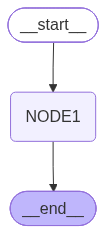

In [ ]:
graph=GraphVar.compile(checkpointer=MemoryVar)
graph

In [ ]:
res=graph.invoke(
    {'message':[SystemMessage(content=" Give Responses in Short and simple "),
                HumanMessage(content="Hello")]},  # Checkpointer requires one or more of the following 'configurable' keys: thread_id
    {"configurable": {'thread_id':'user1'}})
res

{'message': [SystemMessage(content=' Give Responses in Short and simple ', additional_kwargs={}, response_metadata={}),
  HumanMessage(content='Hello', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Hi there!', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f8a1e-12d9-7ea2-aaf2-c4f859cc820d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 40, 'total_tokens': 49, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 37}})]}

In [ ]:
for i in range(len(res['message'])):
    res['message'][i].pretty_print()
#

================================ System Message ================================

 Give Responses in Short and simple 
================================ Human Message =================================

Hello
================================== Ai Message ==================================

Hi there!


First Run 3 msgs

In [ ]:
res=graph.invoke(
    {'message':[ HumanMessage(content="My name is Curcmin")]},  # Checkpointer requires one or more of the following 'configurable' keys: thread_id
    {"configurable": {'thread_id':'user1'}})
res

{'message': [SystemMessage(content=' Give Responses in Short and simple ', additional_kwargs={}, response_metadata={}),
  HumanMessage(content='Hello', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Hi there!', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f8a1e-12d9-7ea2-aaf2-c4f859cc820d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 40, 'total_tokens': 49, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 37}}),
  HumanMessage(content='My name is Curcmin', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Nice to meet you, Curcmin!', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f8a1f-1565-7f42-a5c2-eed484d9fa20-0', tool_call

In [ ]:
for i in range(len(res['message'])):
    res['message'][i].pretty_print()


================================ System Message ================================

 Give Responses in Short and simple 
================================ Human Message =================================

Hello
================================== Ai Message ==================================

Hi there!
================================ Human Message =================================

My name is Curcmin
================================== Ai Message ==================================

Nice to meet you, Curcmin!


Second run 5 [ first  Run 3 msgs + 2in sec run]

In [ ]:
res=graph.invoke(
    {'message':[ HumanMessage(content="What is my name")]},  # Checkpointer requires one or more of the following 'configurable' keys: thread_id
    {"configurable": {'thread_id':'user1'}})
for i in range(len(res['message'])):
    res['message'][i].pretty_print()


================================ System Message ================================

 Give Responses in Short and simple 
================================ Human Message =================================

Hello
================================== Ai Message ==================================

Hi there!
================================ Human Message =================================

My name is Curcmin
================================== Ai Message ==================================

Nice to meet you, Curcmin!
================================ Human Message =================================

What is my name
================================== Ai Message ==================================

Your name is Curcmin.


AI is actually giving correct answers that mean , it actually storing data
- But, It is not reccomended, giving mem to every responses that willm increase token size
- Restricting the Tokens is crutial
- This can be done by adding extra filter Node ontop of Main Bot Node

#### Limiting the Memory

In [2]:
from typing import TypedDict, Annotated, List
from langchain_core.messages import BaseMessage
from operator import add

In [2]:
class ContextMemory(TypedDict):
  Message: Annotated[List[BaseMessage], add]

In [4]:
# Or instead we Can directly import this memory window Funtion from the Langraph
from langgraph.graph import MessagesState
class MessagesState(MessagesState):
  pass

In [3]:
pip install -U langchain-google-genai

In [5]:
## For chat bot we need Interactive Message so first wen need LLM
import os
from google.colab import userdata
os.environ['GOOGLE_API_KEY']=userdata.get('GEMINI4')

In [6]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm=ChatGoogleGenerativeAI(
    model="gemini-2.5-flash")

In [7]:
def ModelNode(state: MessagesState):
  resonse=llm.invoke(state['messages'])
  return {'messages': [resonse]} # We Must return inform of dict[":list]

Here we need to add another Node to filter or limit memory to some messages

In [8]:
from langchain_core.messages import  RemoveMessage

In [9]:
def filter(state: MessagesState):
  limit_Messages=[RemoveMessage(id=msg.id) for msg in state['messages'][:-2]]
  return {'messages': limit_Messages}  # It is already in LIST bcoz we Done list comprehension so no [] in dict is required

---

In [10]:
from langgraph.graph import StateGraph, START, END
Graphvar=StateGraph(MessagesState)

In [11]:
Graphvar.add_node('model',ModelNode)
Graphvar.add_node('filter',filter)

In [12]:
Graphvar.add_edge(START, 'filter')
Graphvar.add_edge('filter', 'model')
Graphvar.add_edge('model', END)

In [13]:
# So here We should give the memeory
from langgraph.checkpoint.memory import InMemorySaver

In [14]:
Memory=InMemorySaver()

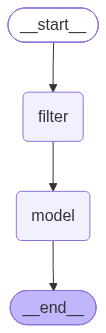

In [15]:
graph=Graphvar.compile(checkpointer=Memory)
graph

In [16]:
from langchain_core.messages import SystemMessage, HumanMessage

In [17]:
res=graph.invoke(
    {'messages':[SystemMessage(content='Give Response in small and simple words'),
                 HumanMessage(content=" What is an AI")]},
    {'configurable':{'thread_id': 'user1'}})
res

{'messages': [SystemMessage(content='Give Response in small and simple words', additional_kwargs={}, response_metadata={}, id='508a7329-580a-4653-b29f-cb5f9b8efdc6'),
  HumanMessage(content=' What is an AI', additional_kwargs={}, response_metadata={}, id='55c7ba5b-36d2-486e-bfda-1227addb530d'),
  AIMessage(content='AI is like making computers smart.\nThey can learn things.\nAnd think a bit, like people do.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f8e4d-4127-7a22-b8a0-73acf44c619c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 214, 'total_tokens': 226, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 191}})]}

In [19]:
for every in res['messages']:
  every.pretty_print()

================================ System Message ================================

Give Response in small and simple words
================================ Human Message =================================

 What is an AI
================================== Ai Message ==================================

AI is like making computers smart.
They can learn things.
And think a bit, like people do.


In [20]:
res=graph.invoke(
    {'messages':[
                 HumanMessage(content=" What is an ML")]},
    {'configurable':{'thread_id': 'user3'}})
res

{'messages': [HumanMessage(content=' What is an ML', additional_kwargs={}, response_metadata={}, id='546fb92d-cc3d-4400-b48f-17828c2cc198'),
  AIMessage(content='An **ML**, which stands for **Machine Learning**, is a field of Artificial Intelligence (AI) that enables computers to learn from data without being explicitly programmed for every specific task.\n\nThink of it like teaching a child: instead of giving the child a precise set of instructions for every single scenario, you show them examples, and they gradually learn to identify patterns and make decisions on their own.\n\nHere\'s a breakdown of what that means:\n\n1.  **Learning from Data:** Instead of a programmer writing code for every possible input and output, an ML system is fed a large amount of data. This data contains examples of the problem it needs to solve.\n\n2.  **Identifying Patterns:** ML algorithms (the "recipes" or "rules" that the computer uses to learn) analyze this data to find correlations, trends, and patt

In [21]:
for every in res['messages']:
  every.pretty_print()

================================ Human Message =================================

 What is an ML
================================== Ai Message ==================================

An **ML**, which stands for **Machine Learning**, is a field of Artificial Intelligence (AI) that enables computers to learn from data without being explicitly programmed for every specific task.

Think of it like teaching a child: instead of giving the child a precise set of instructions for every single scenario, you show them examples, and they gradually learn to identify patterns and make decisions on their own.

Here's a breakdown of what that means:

1.  **Learning from Data:** Instead of a programmer writing code for every possible input and output, an ML system is fed a large amount of data. This data contains examples of the problem it needs to solve.

2.  **Identifying Patterns:** ML algorithms (the "recipes" or "rules" that the computer uses to learn) analyze this data to find correlations, trends, 

In [22]:
res=graph.invoke(
    {'messages':[SystemMessage(content='Give Response in small and simple words'),
                 HumanMessage(content=" My name is Chidvilas ")]},
    {'configurable':{'thread_id': 'user1'}})
for every in res['messages']:
  every.pretty_print()

================================ System Message ================================

Give Response in small and simple words
================================ Human Message =================================

 My name is Chidvilas 
================================== Ai Message ==================================

Hi Chidvilas.


In [23]:
res=graph.invoke(
    {'messages':[SystemMessage(content='Give Response in small and simple words'),
                 HumanMessage(content=" Rohu fish in telugu ")]},
    {'configurable':{'thread_id': 'user1'}})
for every in res['messages']:
  every.pretty_print()

================================ System Message ================================

Give Response in small and simple words
================================ Human Message =================================

 Rohu fish in telugu 
================================== Ai Message ==================================

బోక (Boka)


In [24]:
res=graph.invoke(
    {'messages':[HumanMessage(content=" what is my name ")]},
    {'configurable':{'thread_id': 'user1'}})
for every in res['messages']:
  every.pretty_print()

================================== Ai Message ==================================

బోక (Boka)
================================ Human Message =================================

 what is my name 
================================== Ai Message ==================================

I don't know your name! As an AI, I don't have access to your personal information unless you choose to tell me.

What would you like me to call you?


---

When you limit the messages, you also remove the message that contains your name. The model is not forgetting on its own—you're intentionally removing the information it would need to answer.

This is exactly why LangGraph also teaches memory summarization and long-term memory after context window management. Those techniques preserve important facts while still keeping the context window small.